# Example 1 - Simple 2D Acoustic Simulation

This example builds a small two-layer acoustic model, saves it as a FrequenSolve project, submits a local frequency sweep, and reads the output through the trace API. It uses the current public SDK style: project-owned simulations, `properties={...}` material definitions, Pint quantities at authoring boundaries, mesh grading helpers, automatic save-on-submit, and `TraceDataset` for results.


In [1]:
import numpy as np
import frequensolve as fs

u = fs.ureg

project = fs.Project(
    name="project",
    pretty_name="Simple Simulation",
    path="./scratch/ex_01",
    log_level="DEBUG",
)

sim = project.new_simulation(
    name="simple_acoustic",
    physics="acoustic",
    dimension=2,
)
sim.units.defaults.update(
    {
        "length": u.km,
        "velocity": u.km / u.s,
        "density": u.g / u.cm**3,
    }
)


## Model

Layer material properties are passed as a normal dictionary and remain directly editable through `layer.properties`. Pint quantities serialize to `{value, units}` objects in the solver JSON, while scalar dimensionless properties can stay plain numbers.


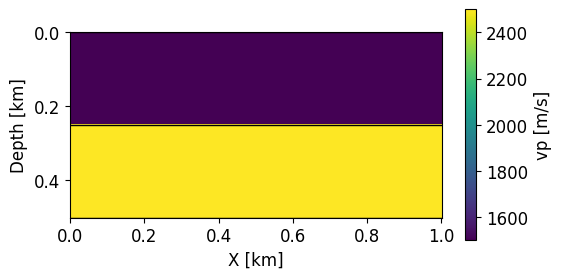

In [2]:
model = fs.LayeredModel(
    name="model",
    dimension=2,
    x_limits=[0.0, 1.0],
)

model.add_surface(name="top", depth=0.0 * u.km)
model.add_layer(
    name="layer_1",
    properties={
        "vp": 1500 * u.m / u.s,
        "rho": 1.0 * u.g / u.cm**3,
        "qp": 300.0,
    },
)
model.add_surface(name="interface", depth=0.25 * u.km)
model.add_layer(
    name="layer_2",
    properties={
        "vp": 2500 * u.m / u.s,
        "rho": 2.2 * u.g / u.cm**3,
        "qp": 500.0,
    },
)
model.add_surface(name="bottom", depth=0.5 * u.km)

# Properties are public and editable.
model.layers[0].properties["qp"] = 350.0

sim += model
model.plot("vp", figsize=(6, 3), aspect="equal")


## Mesh And Boundary Conditions

The initial mesh is intentionally coarse. Frequency-dependent adaptivity and grading rules tell Sauce where to refine during the solve.


In [3]:
sim += model.hex_mesh_generator([4, 4])
sim.mesh.set_adapt(min_epw=2.0, f_adapt=5.0)
sim.mesh.set_source_grading(d1=0.08, d0=0.02, mult=2.0)
sim.mesh.add_surface_grading("interface", d1=0.05, mult=1.5)

bcs = fs.BoundaryConditionManager(label_type="geometric")
bcs += fs.BoundaryCondition(name="free_surface", kind="free", boundaries=["z_min"])
bcs += fs.BoundaryCondition(
    name="absorbing",
    kind="pml",
    boundaries=["x_min", "x_max", "z_max"],
    pml_wavelengths=1.0,
    pml_exponent=3.0,
    pml_constant=5.0,
)
sim += bcs


## Acquisition

Coordinates are physical global coordinates by default. Dense surveys can use arrays directly; sparse surveys can be added later through `SparseSurvey` without changing the rest of the simulation setup.


In [4]:
acq = fs.Acquisition()
acq.add_source_group(
    kind="scalar",
    coords=[[0.5, 0.05]],
)

hydrophone = fs.ReceiverNode(name="hydrophone")
hydrophone.add_component(name="p", field="pressure")

receiver_coords = [[x, 0.02] for x in np.linspace(0.0, 1.0, 201)]
acq.add_receiver_group(
    name="surface",
    device=hydrophone,
    coords=receiver_coords,
)
sim += acq


## Numerics And Outputs

Trace output is enabled by default. ParaView output is optional and can be requested with a small typed output object.


In [5]:
sim += fs.Discretization(order=4)
sim += fs.SolverConfig(tolerance=1.0e-4, grids=3)

# Traces are always exported. Optional outputs are attached to jobs below.

# Explicit saves are available, but site.submit/site.run also saves required inputs.
project.save()
project = fs.Project.load("scratch/ex_01/project.json")
sim = project.simulations["simple_acoustic"]


## Run And Read Traces

`site.submit(job)` returns immediately with a `RunHandle`. Use `run.wait()`, `await run`, or `site.run(job)` when blocking behavior is desired. The returned result can open traces through `TraceDataset`.


In [6]:
site = fs.LocalSite(n_workers=4, shutdown_on_completion=True, verbose=True)

job = fs.TimeDomainJob(
    name="time",
    simulation=sim,
    f_min=0.0,
    f_max=30.0,
    T_max=2.0,
)

run = site.submit(job)
result = run.wait()
traces = result.traces(upscale=4)
print(result.status.state)
print(traces)


skipped
TraceDataset(files=60, frequencies=60, groups=1)


## Plot A Gather

`TraceDataset` exposes groups, components, sources, frequency-domain data, and time-domain data without the old record database layer.


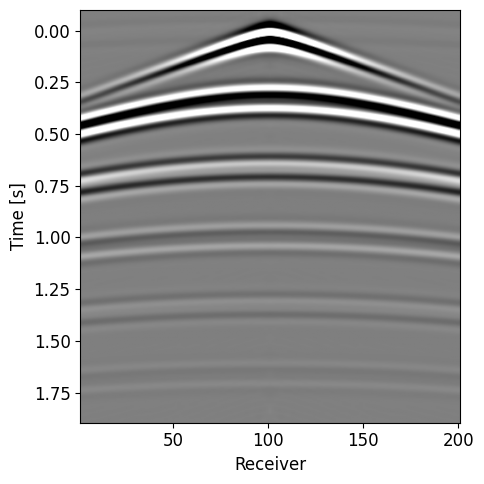

In [7]:
wavelet = fs.RickerWavelet(f=10.0, center=0.1)

group = traces.groups[0]
component = traces.components(group)[0]
source = traces.sources(group)[0]

gather = traces.td(group, component, source, wavelet, upscale=4, T_max=2.0)
fig, ax = fs.plot_gather(
    gather,
    A=2.0 * np.std(np.abs(gather)),
    cmap="gray",
)


## Single-Frequency Jobs

Frequency-domain jobs use the same project, simulation, site, and trace-reading flow.


In [8]:
fd_job = fs.FrequencyDomainJob(
    name="freq_10hz",
    simulation=sim,
    f_list=[30.0],
    outputs=fs.ParaviewOutput(
        name="pv",
        fields=["pressure"],
        properties=["vp", "rho", "Subdomain"],
        show_pml=False,
        upscale=1,
    ),
)

fd_run = site.submit(fd_job)
fd_result = fd_run.wait()
print(fd_result.status.state)


Running: freq_10hz 0/1 |          | Elapsed time: 00:00s

completed


2026-05-01 00:13:54,321 - distributed.core - INFO - Connection to tcp://127.0.0.1:49503 has been closed.


## Plot Frequency-Domain VTU Output


In [9]:
vtu_file = fd_result.output_files(kind="vtk", suffix=".vtu")[-1]
print(vtu_file.name)
print(fs.vtu_fields(vtu_file))

fs.plot_vtu(
    vtu_file,
    field="pressure_1",
    part="im",
    cmap="RdGy",
    vmin=-10.0,
    vmax=10.0,
    show_edges=False,
    scalar_bar=True,
    window_size=(900, 450),
)


pv_00000.vtu
['vp', 'rho', 'Subdomain', 'pressure_1_im', 'pressure_1_re', 'pressure_1_abs']


Widget(value='<iframe src="http://localhost:49535/index.html?ui=P_0x1406b7430_0&reconnect=auto" class="pyvista…